## Preliminaries

In [ ]:
import kagglehub
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Layer,
    Conv1D, MaxPooling1D, UpSampling1D, LayerNormalization, Dropout,
    GRU, LSTM, Dense,
    Flatten, Reshape, RepeatVector, TimeDistributed)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

In [ ]:
def implement_basic_cleaning(data):
    # Fix titles
    data.columns = data.columns.str.strip()

    # Repair time format and set index
    data['Timestamp'] = data['Timestamp'].str.strip()
    data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
    data = data.sort_values('Timestamp', ascending=True)
    data = data.drop_duplicates().dropna()
    data = data.reset_index(drop=True)

    # Encode target feature
    target = 'Normal/Attack'
    data[target] = data[target].map({'Normal':0, 'Attack':1})

    return data

# Execude function
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")
data_complete = implement_basic_cleaning(df)

/tmp/ipykernel_3010/4137876211.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")


100%|██████████| 407M/407M [00:08<00:00, 51.8MB/s]


In [ ]:
X = data_complete.drop(columns={'Timestamp', 'Normal/Attack'})
y = data_complete.iloc[:,-1:]

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

X_samples, X_features = X.shape
train, val = int(X_samples * 0.7), int(X_samples * 0.15)

X_train = X[:train]
X_val = X[train:train + val]
X_test = X[train + val:]

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

scaler = StandardScaler()
pca = PCA(n_components=17, whiten=True)

X_train_scaled = pca.fit_transform(X_train)
X_val_scaled = pca.transform(X_val)
X_test_scaled = pca.transform(X_test)

SAMPLES, FEATURES = X_train_scaled.shape
TIME_STEPS = 96
BATCH_SIZE = 512

## Sequential Modeling Base

In [ ]:
train_input_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_train_scaled,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

val_input_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_val_scaled,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

predict_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=X_test_scaled,
    targets=None,
    sequence_length=TIME_STEPS,
    batch_size=BATCH_SIZE,
    shuffle=False)

def set_shape(x):
    x.set_shape([None, TIME_STEPS, FEATURES])
    return x, x

train_ds = train_input_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_input_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = predict_ds.map(set_shape).prefetch(buffer_size=tf.data.AUTOTUNE)

### LSTM Autoencoder

In [ ]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class LSTM_VAE(tf.keras.Model):
    def __init__(self, time_steps, features, latent_dim, dropout):
        super().__init__()

        self.encoder = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(time_steps, features)),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=32, return_sequences=True),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=16, return_sequences=False)
        ])

        self.get_mean = Dense(latent_dim, name='z_mean')
        self.get_log_var = Dense(latent_dim, name='z_log_var')

        self.sampling = Sampling()
        self.z_space = RepeatVector(time_steps)

        self.decoder = Sequential([
            LSTM(units=latent_dim, return_sequences=True, input_shape=(time_steps, latent_dim)),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=32, return_sequences=True),
            LayerNormalization(),
            Dropout(dropout),
            LSTM(units=64, return_sequences=True),
            TimeDistributed(Dense(features))
        ])


    def call(self, X):
        h = self.encoder(X)

        z_mean = self.get_mean(h)
        z_log_var = self.get_log_var(h)
        z = self.sampling([z_mean, z_log_var])
        z_copy = self.z_space(z)

        X_recon = self.decoder(z_copy)

        reconstruction_loss = tf.reduce_mean(tf.reduce_mean(tf.square(X - X_recon), axis=[1, 2]))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        )
        total_loss = reconstruction_loss + kl_loss

        self.add_loss(total_loss)

        return X_recon


model = LSTM_VAE(time_steps=TIME_STEPS,
               features=FEATURES,
               latent_dim=8,
               dropout=0.2)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

checkpoint_path_lstm = "checkpoints_lstm/model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.weights.h5"
checkpoint_lstm = ModelCheckpoint(
    filepath=checkpoint_path_lstm,
    monitor='val_loss',
    save_best_only=True,      # Saves only when validation loss improves
    mode='min',
    save_weights_only=True,  # Saves the entire model architecture + weights
    verbose=1)
stoppage = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    verbose=1)


history = model.fit(train_ds,
                    epochs=30,
                    verbose=1,
                    validation_data=val_ds,
                    callbacks=[stoppage, lr_scheduler, checkpoint_lstm],
                    shuffle=False)

print("Training complete! Final Loss:", history.history['loss'][-1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 1.0550
Epoch 1: val_loss improved from None to 0.76475, saving model to checkpoints_lstm/model_epoch_01_val_loss_0.7648.weights.h5

Epoch 1: finished saving model to checkpoints_lstm/model_epoch_01_val_loss_0.7648.weights.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 68s 93ms/step - loss: 0.8793 - val_loss: 0.7648 - learning_rate: 0.0010
Epoch 2/30
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.9737
Epoch 2: val_loss did not improve from 0.76475
615/615 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - loss: 0.8939 - val_loss: 0.7932 - learning_rate: 0.0010
Epoch 3/30
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.9662
Epoch 3: val_loss did not improve from 0.76475
615/615 ━━━━━━━━━━━━━━━━━━━━ 53s 86ms/step - loss: 0.8690 - val_loss: 0.7659 - learning_rate: 0.0010
Epoch 4/30
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.9421
Epoch 4: val_loss improved from 0.76475 to 0.75476, saving model to checkpoints_lstm/model_epoch_04_val_loss_0.75

In [ ]:
test_errors = []
all_test_sequences = []

for X_test_batch, _ in test_ds:
    X_test_recon = model(X_test_batch, training=False)

    # Calculate MAE per sequence
    mae_per_step = tf.reduce_mean(tf.abs(X_test_batch - X_test_recon), axis=-1)
    mae_per_sequence = tf.reduce_mean(mae_per_step, axis=1)

    test_errors.extend(mae_per_sequence.numpy())
    all_test_sequences.extend(X_test_batch.numpy())

test_errors = np.array(test_errors)
all_test_sequences = np.array(all_test_sequences)

# Flag sequences that exceed the threshold
anomaly_mask = test_errors > threshold
anomaly_indices = np.where(anomaly_mask)[0]

print(f"Detected {len(anomaly_indices)} anomalies out of {len(test_errors)} test sequences.")

Detected 5019 anomalies out of 67394 test sequences.


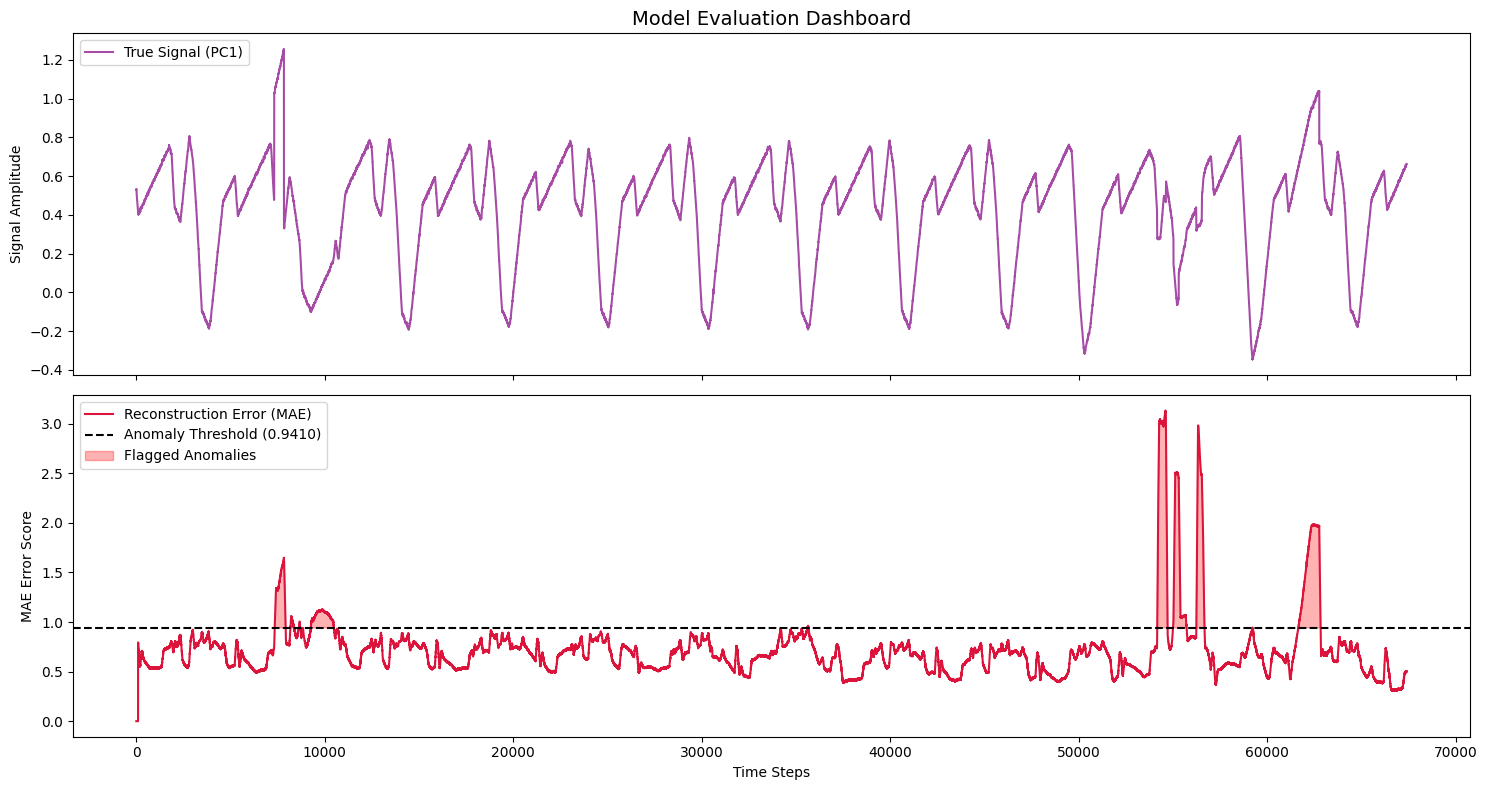

In [ ]:
# 1. Extract the actual first principal component across the entire test timeline
# We flatten the overlapping time steps to get a continuous sequence
true_timeline = []
for X_test_batch, _ in test_ds:
    # Taking the first step of each sequence to reconstruct a continuous timeline
    true_timeline.extend(X_test_batch.numpy()[:, 0, 0])

# 2. Align your test error scores to this timeline
# (Note: Since test_errors is calculated per 96-step window, we pad the beginning
# so it lines up with the timeline perfectly)
padded_errors = np.zeros(len(true_timeline))
padded_errors[TIME_STEPS-1:] = test_errors[:len(true_timeline)-(TIME_STEPS-1)]

# 3. Create the dual-plot evaluation chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top Plot: The True Signal (PC1)
ax1.plot(true_timeline, color='purple', label='True Signal (PC1)', alpha=0.7)
ax1.set_title("Model Evaluation Dashboard", fontsize=14)
ax1.set_ylabel("Signal Amplitude")
ax1.legend(loc='upper left')

# Bottom Plot: Reconstruction Error vs Threshold
ax2.plot(padded_errors, color='crimson', label='Reconstruction Error (MAE)')
ax2.axhline(y=threshold, color='black', linestyle='--', label=f'Anomaly Threshold ({threshold:.4f})')
ax2.fill_between(range(len(padded_errors)), padded_errors, threshold,
                 where=(padded_errors > threshold), color='red', alpha=0.3, label='Flagged Anomalies')
ax2.set_ylabel("MAE Error Score")
ax2.set_xlabel("Time Steps")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

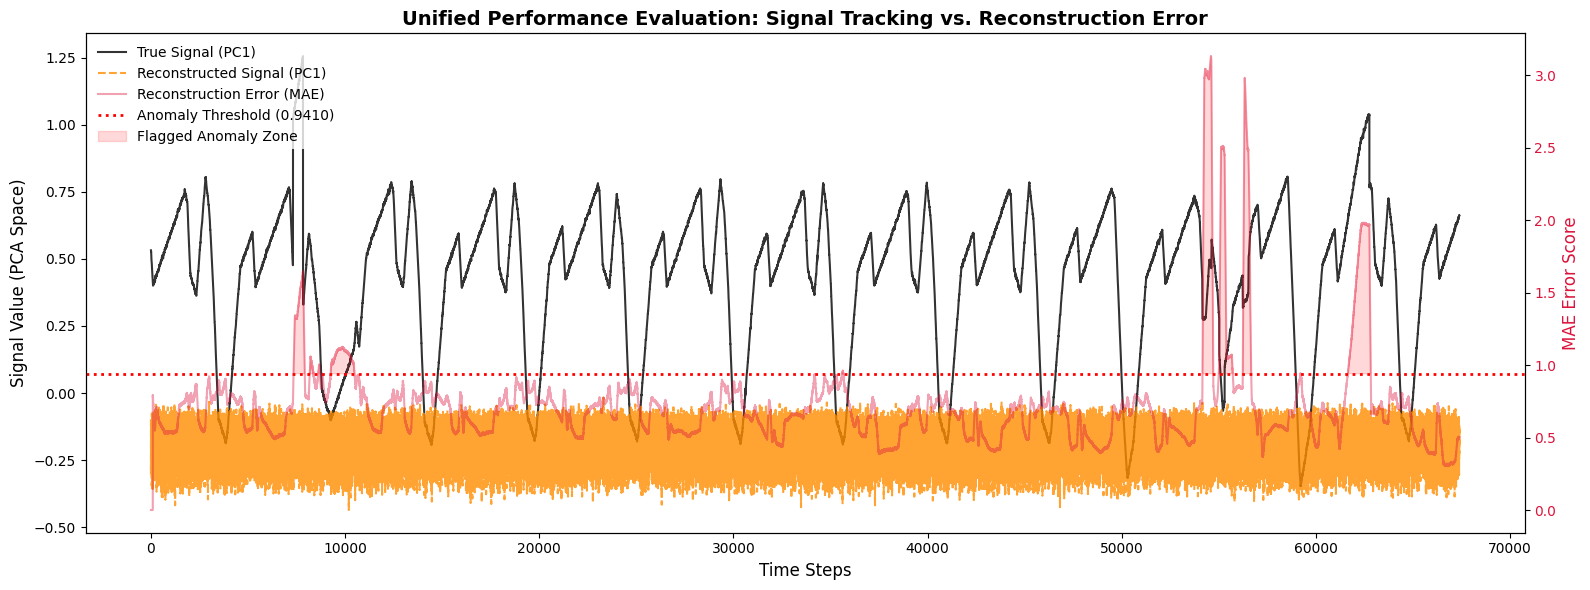

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Rebuild the continuous true and reconstructed timelines for PC1
true_timeline = []
recon_timeline = []

for X_test_batch, _ in test_ds:
    X_test_recon = model(X_test_batch, training=False)

    # Grab the first step of each sequence for the first principal component (PC1)
    true_timeline.extend(X_test_batch.numpy()[:, 0, 0])
    recon_timeline.extend(X_test_recon.numpy()[:, 0, 0])

true_timeline = np.array(true_timeline)
recon_timeline = np.array(recon_timeline)

# 2. Align your test error scores to this timeline
padded_errors = np.zeros(len(true_timeline))
padded_errors[TIME_STEPS-1:] = test_errors[:len(true_timeline)-(TIME_STEPS-1)]

# 3. Create the Unified Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(16, 6))

# --- Left Y-Axis: Signals ---
color_true = 'black'
color_recon = 'darkorange'
ax1.plot(true_timeline, color=color_true, label='True Signal (PC1)', alpha=0.8, linewidth=1.5)
ax1.plot(recon_timeline, color=color_recon, linestyle='--', label='Reconstructed Signal (PC1)', alpha=0.8, linewidth=1.5)

ax1.set_xlabel('Time Steps', fontsize=12)
ax1.set_ylabel('Signal Value (PCA Space)', color=color_true, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_true)
ax1.set_title("Unified Performance Evaluation: Signal Tracking vs. Reconstruction Error", fontsize=14, fontweight='bold')

# --- Right Y-Axis: Error & Threshold ---
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color_error = 'crimson'
ax2.plot(padded_errors, color=color_error, label='Reconstruction Error (MAE)', alpha=0.4)
ax2.axhline(y=threshold, color='red', linestyle=':', linewidth=2, label=f'Anomaly Threshold ({threshold:.4f})')

# Shade the background where anomalies are flagged
ax2.fill_between(range(len(padded_errors)), padded_errors, threshold,
                 where=(padded_errors > threshold), color='red', alpha=0.15, label='Flagged Anomaly Zone')

ax2.set_ylabel('MAE Error Score', color=color_error, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_error)

# --- Combine Legends ---
# Since we used two different axes, we combine their legends so it looks clean
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### TCN Autoencoder

In [ ]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), dtype=z_mean.dtype)

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class TCN_AE(tf.keras.Model):
    def __init__(self, time_steps, features, latent_dim):
        super().__init__()

        self.time_steps = time_steps
        self.features = features
        self.latent_dim = latent_dim

        self.encoder = Sequential([
            Conv1D(filters=128, kernel_size=3, padding='causal', activation='relu', input_shape=(time_steps, features)),
            Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu', dilation_rate=2),
            Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu', dilation_rate=4),
            Conv1D(filters=16, kernel_size=3, padding='causal', activation='relu', dilation_rate=16),
            Flatten()
        ])

        self.get_mean = Dense(latent_dim, name='z_mean')
        self.get_log_var = Dense(latent_dim, name='z_log_var')
        self.sampling = Sampling()

        self.decoder_input = Dense(TIME_STEPS * 16, activation='relu')
        self.reshape = Reshape((time_steps, 16))


        self.decoder = Sequential([
            Conv1D(filters=16, kernel_size=3, padding='same', activation='relu'),
            Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
            Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
            Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
            Conv1D(filters=features, kernel_size=3, activation='linear', padding='same')
        ])


    def call(self, X):
        h = self.encoder(X)
        z_mean = self.get_mean(h)
        z_log_var = self.get_log_var(h)
        z = self.sampling([z_mean, z_log_var])

        X_decoded = self.decoder_input(z)
        X_decoded = self.reshape_layer(X_decoded)

        X_recon = self.decoder(X_decoded)

        reconstruction_loss = tf.reduce_mean(tf.square(X - X_recon))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        )
        total_loss = reconstruction_loss + kl_loss

        self.add_loss(total_loss)

        return X_recon

In [ ]:
model = TCN_AE(
    time_steps=TIME_STEPS,
    features=FEATURES,
    latent_dim=8)
model.build(input_shape=(None, TIME_STEPS, FEATURES))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

checkpoint_path_cnn = "checkpoints/model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.weights.h5"
checkpoint_cnn = ModelCheckpoint(
    filepath=checkpoint_path_cnn,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    save_weights_only=True,
    verbose=1)
stoppage = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1)


history = model.fit(
    train_ds,
    epochs=20,
    verbose=1,
    validation_data=val_ds,
    callbacks=[stoppage, lr_scheduler, checkpoint_cnn],
    shuffle=False # Note: If using tf.data.Dataset, shuffling is handled inside the pipeline above
)

print("Training complete! Final Loss:", history.history['loss'][-1])

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'tcn_ae_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


AttributeError: Exception encountered when calling TCN_AE.call().

[1m'TCN_AE' object has no attribute 'reshape_layer'[0m

Arguments received by TCN_AE.call():
  • X=tf.Tensor(shape=(None, 96, 17), dtype=float32)